# 03 - Feature Engineering

## Objective
Build the modeling-ready feature set from weekly sales + weather data.

## Features Created
1. **Seasonality** — Fourier terms (week-of-year)
2. **Calendar** — holidays, season flags, year index
3. **Weather** — raw values + deviation z-scores from monthly norms
4. **Sales lags** — 1w, 2w, 4w lags + 4-week rolling mean/std


## Input
- `data/processed/weekly_sales_weather.csv`

## Output
- `data/processed/modeling_dataset.csv`
---

---
## Cell 1: Imports
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette('husl')

PROJECT_ROOT   = Path('..')
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES        = PROJECT_ROOT / 'reports' / 'figures'
print('✅ Imports complete')

✅ Imports complete


---
## Cell 2: Load Data
---

In [2]:
df = pd.read_csv(DATA_PROCESSED / 'weekly_units_weather.csv')
df['week_ending'] = pd.to_datetime(df['week_ending'])
df = df.sort_values(['store_code','division_code','week_ending']).reset_index(drop=True)

GROUP_COLS = ['store_code','city','division_code']

print(f'Dataset: {df.shape}')
print(f'Date range: {df["week_ending"].min().date()} → {df["week_ending"].max().date()}')
print(f'Columns: {df.columns.tolist()}')

Dataset: (49148, 24)
Date range: 2023-11-05 → 2026-03-15
Columns: ['week_ending', 'store_code', 'city', 'province', 'division_code', 'units', 'gross_units', 'returns', 'n_transactions', 'avg_temp', 'max_temp', 'total_precip', 'sunshine_hours', 'rain_days', 'snow_days', 'bad_weather_days', 'max_wind', 'feels_like_max', 'weekend_avg_temp', 'weekend_bad_weather', 'n_days_in_week', 'n_holidays', 'has_holiday', 'month']


---
## Cell 3: Seasonality Features (Fourier Terms)

---

In [3]:
df['week_of_yr'] = df['week_ending'].dt.isocalendar().week.astype(int)
df['month']      = df['week_ending'].dt.month
df['year']       = df['week_ending'].dt.year

# Annual Fourier (period = 52 weeks)
df['sin_week_1'] = np.sin(2 * np.pi * df['week_of_yr'] / 52)
df['cos_week_1'] = np.cos(2 * np.pi * df['week_of_yr'] / 52)
df['sin_week_2'] = np.sin(4 * np.pi * df['week_of_yr'] / 52)
df['cos_week_2'] = np.cos(4 * np.pi * df['week_of_yr'] / 52)

# Monthly Fourier (period = 12 months)
df['sin_month_1'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month_1'] = np.cos(2 * np.pi * df['month'] / 12)

SEASONALITY_FEATURES = ['sin_week_1','cos_week_1','sin_week_2','cos_week_2',
                         'sin_month_1','cos_month_1']
print(f'✅ Seasonality features: {SEASONALITY_FEATURES}')

✅ Seasonality features: ['sin_week_1', 'cos_week_1', 'sin_week_2', 'cos_week_2', 'sin_month_1', 'cos_month_1']


---
## Cell 4: Calendar Features
---

In [4]:
df['year_idx'] = df['year'] - df['year'].min()  # Trend term
df['quarter']  = df['week_ending'].dt.quarter

# Season flags relevant to pool/spa franchise
df['is_summer_peak']    = df['month'].isin([6, 7, 8]).astype(int)
df['is_spring_opening'] = df['month'].isin([4, 5]).astype(int)
df['is_fall_closing']   = df['month'].isin([9, 10]).astype(int)
df['is_winter_off']     = df['month'].isin([11, 12, 1, 2, 3]).astype(int)

# n_holidays and has_holiday already present from 02_weather_integration.ipynb
CALENDAR_FEATURES = ['year_idx','quarter','week_of_yr','has_holiday','n_holidays',
                      'is_summer_peak','is_spring_opening','is_fall_closing']
print(f'✅ Calendar features: {CALENDAR_FEATURES}')

✅ Calendar features: ['year_idx', 'quarter', 'week_of_yr', 'has_holiday', 'n_holidays', 'is_summer_peak', 'is_spring_opening', 'is_fall_closing']


---
## Cell 4b: Quebec-Specific Holiday Features

Key demand-shaping events for a Quebec pool/spa retailer.
These are computed from date features only — no hardcoded years.

---

In [5]:
# Construction Holiday: ~last 2 full weeks of July (ISO weeks 29-30)
df['is_construction_holiday'] = (
    (df['month'] == 7) & (df['week_of_yr'].isin([29, 30]))
).astype(int)

# St-Jean-Baptiste: June 24 — flag the week containing it (typically ISO week 25 or 26)
df['is_st_jean_week'] = (
    (df['month'] == 6) & (df['week_of_yr'].isin([25, 26]))
).astype(int)

# Victoria Day: Monday before May 25 — typically ISO week 20 or 21
df['is_victoria_day_week'] = (
    (df['month'] == 5) & (df['week_of_yr'].isin([20, 21]))
).astype(int)

# Labour Day: first Monday of September — first week of Sept
df['is_labour_day_week'] = (
    (df['month'] == 9) & (df['week_ending'].dt.day <= 7)
).astype(int)

# Pool season indicator (May through September)
df['is_pool_season'] = df['month'].isin([5, 6, 7, 8, 9]).astype(int)

QC_HOLIDAY_FEATURES = [
    'is_construction_holiday', 'is_st_jean_week',
    'is_victoria_day_week', 'is_labour_day_week', 'is_pool_season'
]
print(f'✅ Quebec holiday features: {QC_HOLIDAY_FEATURES}')
print(f'   Construction holiday weeks: {df["is_construction_holiday"].sum():,}')
print(f'   St-Jean weeks: {df["is_st_jean_week"].sum():,}')
print(f'   Pool season weeks: {df["is_pool_season"].sum():,}')

✅ Quebec holiday features: ['is_construction_holiday', 'is_st_jean_week', 'is_victoria_day_week', 'is_labour_day_week', 'is_pool_season']
   Construction holiday weeks: 1,964
   St-Jean weeks: 1,956
   Pool season weeks: 21,391


---
## Cell 4c: Division-Specific Seasonality

Different product categories have different seasonal profiles.
Pool divisions peak in summer; fitness peaks in winter.

---

In [6]:
POOL_DIVS = {'PC', 'CH', 'LO', 'AP', 'SEC', 'DO'}
OUTDOOR_DIVS = {'ME', 'GA', 'BQ', 'PA'}
FITNESS_DIVS = {'FI', 'CR'}

df['is_pool_div'] = df['division_code'].isin(POOL_DIVS).astype(int)
df['is_outdoor_div'] = df['division_code'].isin(OUTDOOR_DIVS).astype(int)
df['is_fitness_div'] = df['division_code'].isin(FITNESS_DIVS).astype(int)

# Division x Season interactions
df['pool_div_x_summer'] = df['is_pool_div'] * df['is_summer_peak']
df['pool_div_x_spring'] = df['is_pool_div'] * df['is_spring_opening']
df['outdoor_div_x_summer'] = df['is_outdoor_div'] * df['is_summer_peak']
df['fitness_div_x_winter'] = df['is_fitness_div'] * df['is_winter_off']

DIV_SEASON_FEATURES = [
    'is_pool_div', 'is_outdoor_div', 'is_fitness_div',
    'pool_div_x_summer', 'pool_div_x_spring',
    'outdoor_div_x_summer', 'fitness_div_x_winter'
]
print(f'✅ Division-season features: {DIV_SEASON_FEATURES}')

✅ Division-season features: ['is_pool_div', 'is_outdoor_div', 'is_fitness_div', 'pool_div_x_summer', 'pool_div_x_spring', 'outdoor_div_x_summer', 'fitness_div_x_winter']


---
## Cell 5: Weather Feature Engineering

Two approaches:
1. **Raw values** — direct weather readings
2. **Deviation z-scores** — deviation from monthly city norm (orthogonal to Fourier seasonality)

QC stores (Longueuil, Gatineau, St-Constant, Beloeil) have similar climate.
Nepean (ON) is slightly different and is treated separately via the city-level merge.
---

In [7]:
WEATHER_RAW = [
    'avg_temp',
    'total_precip',
    'sunshine_hours',
    'snow_days'
]

for col in WEATHER_RAW:
    if col not in df.columns:
        continue
    # Use per-year-month norms to avoid data leakage from future periods
    monthly_avg       = df.groupby(['city','year','month'])[col].transform('mean')
    df[f'{col}_dev']  = df[col] - monthly_avg
    dev_std           = df[f'{col}_dev'].std()
    df[f'{col}_dev_z']= df[f'{col}_dev'] / dev_std if dev_std > 0 else 0.0

# Temperature threshold flags (important for pool/spa demand triggers)
df['temp_above_20']       = (df['avg_temp'] > 20).astype(int)  # Pool weather
df['temp_above_25']       = (df['avg_temp'] > 25).astype(int)  # Peak pool demand
df['temp_below_0']        = (df['avg_temp'] < 0).astype(int)   # Winter
df['cooling_degree_days'] = (df['avg_temp'] - 18).clip(lower=0)
df['heating_degree_days'] = (18 - df['avg_temp']).clip(lower=0)
df['heavy_rain'] = (df['total_precip'] > 10).astype(int)
df['very_hot']   = (df['avg_temp'] > 30).astype(int)


WEATHER_FEATURES = (
    WEATHER_RAW
    + [f'{c}_dev_z' for c in WEATHER_RAW if c in df.columns]
    + ['temp_above_20','temp_above_25','temp_below_0',
       'cooling_degree_days','heating_degree_days', 'heavy_rain','very_hot']
)
print(f'✅ Weather features: {len([c for c in WEATHER_FEATURES if c in df.columns])} features')

✅ Weather features: 15 features


---
## Cell 5b: Weather × Season Interaction Features

The impact of weather on demand is season-dependent.
A 25°C day in April drives massive demand; in August it's normal.

---

In [8]:
df['temp_x_summer'] = df['avg_temp'] * df['is_summer_peak']
df['temp_x_spring'] = df['avg_temp'] * df['is_spring_opening']
df['sunshine_x_summer'] = df['sunshine_hours'] * df['is_summer_peak']
df['bad_weather_x_summer'] = df['bad_weather_days'] * df['is_summer_peak']

# Pool season temperature interaction
df['temp_x_pool_season'] = df['avg_temp'] * df['is_pool_season']

INTERACTION_FEATURES = [
    'temp_x_summer', 'temp_x_spring',
    'sunshine_x_summer', 'bad_weather_x_summer',
    'temp_x_pool_season'
]
print(f'✅ Interaction features: {INTERACTION_FEATURES}')

✅ Interaction features: ['temp_x_summer', 'temp_x_spring', 'sunshine_x_summer', 'bad_weather_x_summer', 'temp_x_pool_season']


---
## Cell 6: Sales Lag & Rolling Features

Applied per `store_code × division_code` group to avoid cross-series leakage.

**Note:** These are for model comparison (XGBoost etc.).
Prophet does NOT use lag features — it models autocorrelation internally.
---

In [9]:
def add_weather_lags(group):
    group = group.sort_values('week_ending').copy()

    group['temp_lag1'] = group['avg_temp'].shift(1)
    group['temp_lag2'] = group['avg_temp'].shift(2)

    group['precip_lag1'] = group['total_precip'].shift(1)

    return group

df = df.groupby(GROUP_COLS, group_keys=False).apply(add_weather_lags)

WEATHER_LAG_FEATURES = [
    'temp_lag1',
    'temp_lag2',
    'precip_lag1'
]

print(f'✅ Weather lag features: {WEATHER_LAG_FEATURES}')


def add_lag_features(group):
    group = group.sort_values('week_ending').copy()

    for lag in [1, 2, 4, 8]:
        group[f'units_lag_{lag}w'] = group['units'].shift(lag)

    group['units_roll4_mean'] = group['units'].shift(1).rolling(4, min_periods=2).mean()
    group['units_roll4_std']  = group['units'].shift(1).rolling(4, min_periods=2).std()

    group['units_roll12_mean'] = group['units'].shift(1).rolling(12, min_periods=4).mean()

    # Year-over-year lag (same week last year) — strongest predictor for seasonal retail
    group['units_lag_52w'] = group['units'].shift(52)
    group['units_yoy_change'] = (
        (group['units'] - group['units'].shift(52)) /
        group['units'].shift(52).replace(0, np.nan)
    )

    return group

df = df.groupby(GROUP_COLS, group_keys=False).apply(add_lag_features)

LAG_FEATURES = [
    'units_lag_1w',
    'units_lag_2w',
    'units_lag_4w',
    'units_lag_8w',
    'units_roll4_mean',
    'units_roll4_std',
    'units_roll12_mean',
    'units_lag_52w',
    'units_yoy_change'
]
print(f'✅ Lag features: {LAG_FEATURES}')
print(f'NaN counts (expected at series start):')
print(df[LAG_FEATURES].isna().sum())

✅ Weather lag features: ['temp_lag1', 'temp_lag2', 'precip_lag1']
✅ Lag features: ['units_lag_1w', 'units_lag_2w', 'units_lag_4w', 'units_lag_8w', 'units_roll4_mean', 'units_roll4_std', 'units_roll12_mean', 'units_lag_52w', 'units_yoy_change']
NaN counts (expected at series start):
units_lag_1w           711
units_lag_2w          1402
units_lag_4w          2742
units_lag_8w          5327
units_roll4_mean      1402
units_roll4_std       1402
units_roll12_mean     2742
units_lag_52w        29626
units_yoy_change     29829
dtype: int64


---
## Cell 7: Feature Correlation with Sales
---

Feature correlations with weekly sales (top 20):
  units_roll4_mean                    +0.773  ███████████████
  units_lag_1w                        +0.726  ██████████████
  units_lag_2w                        +0.709  ██████████████
  units_roll12_mean                   +0.677  █████████████
  units_lag_52w                       +0.671  █████████████
  units_lag_4w                        +0.629  ████████████
  units_roll4_std                     +0.534  ██████████
  units_lag_8w                        +0.500  ██████████
  avg_temp                            +0.126  ██
  temp_lag1                           +0.109  ██
  sunshine_hours                      +0.104  ██
  is_spring_opening                   +0.103  ██
  units_yoy_change                    +0.100  ██
  temp_lag2                           +0.092  █
  is_summer_peak                      +0.077  █
  cooling_degree_days                 +0.053  █
  temp_above_20                       +0.047  
  total_precip                        

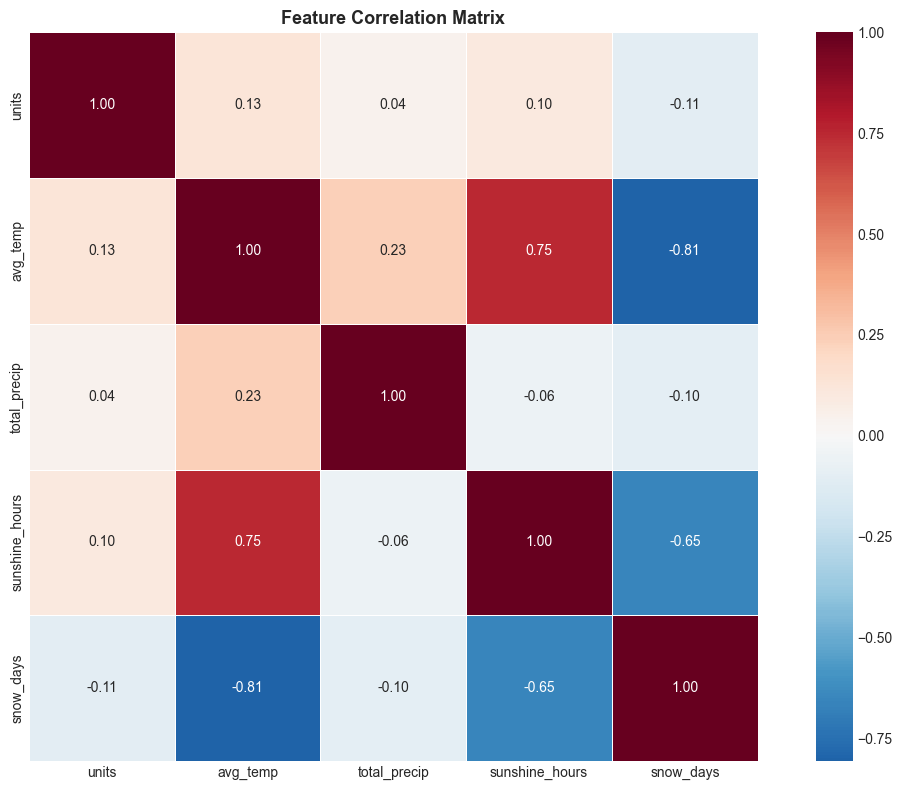

✅ Saved: feature_correlation.png

Division-specific correlations with sales:
AB    avg_temp vs sales correlation: 0.090
AM    avg_temp vs sales correlation: 0.014
AP    avg_temp vs sales correlation: 0.340
AS    avg_temp vs sales correlation: 0.247
AZ    avg_temp vs sales correlation: 0.089
BI    avg_temp vs sales correlation: -0.167
BQ    avg_temp vs sales correlation: 0.331
CA    avg_temp vs sales correlation: 0.028
CC    avg_temp vs sales correlation: -0.025
CH    avg_temp vs sales correlation: 0.246
CM    avg_temp vs sales correlation: -1.000
CR    avg_temp vs sales correlation: -0.090
DI    avg_temp vs sales correlation: 0.054
DO    avg_temp vs sales correlation: 0.428
FI    avg_temp vs sales correlation: -0.075
GA    avg_temp vs sales correlation: 0.121
HT    avg_temp vs sales correlation: 0.166
IN    avg_temp vs sales correlation: 0.051
INM   avg_temp vs sales correlation: 0.044
LI    avg_temp vs sales correlation: 0.064
LO    avg_temp vs sales correlation: 0.530
ME    avg_temp 

In [10]:
all_feat = (
    SEASONALITY_FEATURES
    + CALENDAR_FEATURES
    + [c for c in WEATHER_FEATURES if c in df.columns]
    + WEATHER_LAG_FEATURES
    + [c for c in LAG_FEATURES if c in df.columns]
)
all_feat = [c for c in all_feat if c in df.columns]

corr = df[['units'] + all_feat].corr()['units'].drop('units').sort_values(ascending=False)

print('Feature correlations with weekly sales (top 20):')
print('='*50)
for feat, val in corr.head(20).items():
    bar  = '█' * int(abs(val) * 20)
    sign = '+' if val >= 0 else '-'
    print(f'  {feat:<35} {sign}{abs(val):.3f}  {bar}')

# Heatmap: weather vs sales
hm_cols = ['units'] + [c for c in WEATHER_RAW if c in df.columns]
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df[hm_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: feature_correlation.png')

print("\nDivision-specific correlations with sales:")
print("="*50)

for div, g in df.groupby('division_code'):
    corr = g[['units','avg_temp']].corr().iloc[0,1]
    print(f'{div:<5} avg_temp vs sales correlation: {corr:.3f}')

---
## Cell 7b: Log-Transform & Feature Redundancy Check
---

In [11]:
# Log transform of target (optional alternative for models)
df['log_units'] = np.log1p(df['units'])
print(f"units skewness:     {df['units'].skew():.3f}")
print(f"log_units skewness: {df['log_units'].skew():.3f}")

# Feature redundancy check (|r| > 0.9)
all_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude keys and targets
exclude = ['units', 'log_units', 'gross_units', 'returns', 'n_transactions', 'sales']
feat_cols = [c for c in all_numeric if c not in exclude]

corr_matrix = df[feat_cols].corr()
high_corr = []
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.9:
            high_corr.append((corr_matrix.index[i], corr_matrix.columns[j], round(r, 3)))

print(f"\nHighly correlated feature pairs (|r| > 0.9): {len(high_corr)}")
for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True)[:15]:
    print(f"  {f1:<35} ↔ {f2:<35} r={r}")
if len(high_corr) > 15:
    print(f"  ... and {len(high_corr) - 15} more")
print("\n⚠️ No features dropped — redundancy is documented for future selection.")

units skewness:     11.517
log_units skewness: 0.889

Highly correlated feature pairs (|r| > 0.9): 34
  year                                ↔ year_idx                            r=1.0
  avg_temp_dev                        ↔ avg_temp_dev_z                      r=1.0
  total_precip_dev                    ↔ total_precip_dev_z                  r=1.0
  sunshine_hours_dev                  ↔ sunshine_hours_dev_z                r=1.0
  snow_days_dev                       ↔ snow_days_dev_z                     r=1.0
  n_holidays                          ↔ has_holiday                         r=0.999
  max_temp                            ↔ feels_like_max                      r=0.998
  avg_temp                            ↔ max_temp                            r=0.996
  month                               ↔ week_of_yr                          r=0.996
  avg_temp                            ↔ feels_like_max                      r=0.995
  avg_temp                            ↔ heating_degree_days         

---
## Cell 8: Save Modeling Dataset
---

In [12]:
# ── NB04 Compatibility Check ─────────────────────────────────────────────────
NB04_REQUIRED = [
    'week_ending', 'store_code', 'city', 'division_code', 'units',
    'avg_temp', 'temp_above_25', 'bad_weather_days', 'snow_days',
    'sunshine_hours', 'has_holiday', 'heating_degree_days',
    'units_lag_1w', 'units_lag_2w', 'units_lag_4w', 'units_lag_8w',
    'units_roll4_mean', 'units_roll4_std', 'units_roll12_mean',
    'sin_week_1', 'cos_week_1', 'sin_week_2', 'cos_week_2',
    'sin_month_1', 'cos_month_1', 'year_idx',
    'is_summer_peak', 'is_spring_opening', 'is_fall_closing',
    'week_of_yr', 'month',
]
missing = [c for c in NB04_REQUIRED if c not in df.columns]
assert not missing, f"Missing NB04-required columns: {missing}"
print(f"✅ NB04 compatibility: PASSED ({len(NB04_REQUIRED)} required columns present)")

df.to_csv(DATA_PROCESSED / 'modeling_dataset.csv', index=False)
print(f'✅ Saved: modeling_dataset.csv ({df.shape[0]:,} rows × {df.shape[1]} cols)')
print("""
Feature Summary:
  Seasonality     : sin/cos Fourier terms (week + month)
  Calendar        : year_idx, quarter, season flags, holidays
  QC Holidays     : construction holiday, St-Jean, Victoria Day, Labour Day, pool season
  Division-Season : pool/outdoor/fitness division flags + season interactions
  Weather (raw)   : avg_temp, total_precip, sunshine_hours, rain_days, snow_days, bad_weather_days
  Weather (dev)   : *_dev_z (z-score deviation from year-month city norm)
  Thresholds      : temp_above_20/25, temp_below_0, cooling/heating degree days
  Interactions    : temp/sunshine/bad_weather × summer/spring/pool_season
  Lag features    : 1w, 2w, 4w, 8w, 52w lags + 4/12-week rolling + YoY change
  Log target      : log_units (log1p transform)

Next → 04_forecast_model.ipynb
""")

✅ NB04 compatibility: PASSED (31 required columns present)
✅ Saved: modeling_dataset.csv (49,148 rows × 83 cols)

Feature Summary:
  Seasonality     : sin/cos Fourier terms (week + month)
  Calendar        : year_idx, quarter, season flags, holidays
  QC Holidays     : construction holiday, St-Jean, Victoria Day, Labour Day, pool season
  Division-Season : pool/outdoor/fitness division flags + season interactions
  Weather (raw)   : avg_temp, total_precip, sunshine_hours, rain_days, snow_days, bad_weather_days
  Weather (dev)   : *_dev_z (z-score deviation from year-month city norm)
  Thresholds      : temp_above_20/25, temp_below_0, cooling/heating degree days
  Interactions    : temp/sunshine/bad_weather × summer/spring/pool_season
  Lag features    : 1w, 2w, 4w, 8w, 52w lags + 4/12-week rolling + YoY change
  Log target      : log_units (log1p transform)

Next → 04_forecast_model.ipynb

